# Pulsed vs Continuous Plasma Control — Quick Demo

This notebook runs a **single physics regime** through three controller types
(constant, pulse train, kick-hold) under two conditions (clean and degraded)
and plots the results inline.

The model includes a **resolution scale** ℓ(t) that mediates both barrier
washout and observation noise degradation.

**Runtime: ~3 min.** For the full 4-regime comparison, see `run_comparison.py`.


In [1]:
import sys, os, numpy as np
sys.path.insert(0, os.path.abspath("."))

from src.physics_sampling import params_from_sample
from src.simulate import run_simulation, choose_dt
from src.controllers import make_constant, make_pulse_train, make_kick_hold
from src.metrics import compute_metrics

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Physics regime & degradation handles

All parameters are exposed here — tweak and re-run to explore.

In [2]:
# ── Physics (pulse-friendly: slow barrier, fast ℓ relaxation) ──────────
SAMPLE = {
    "tau0": 1.0, "tauB": 8.0, "kappa": 8.0, "eta": 0.6, "beta": 0.001,
    "gamma_wash": 0.05, "lambda_wash": 0.8,
    "P_hold_frac": 0.05, "tau_decay_frac": 0.8,
    "W_on": 0.9, "W_off": 0.6, "P_on_frac": 0.5, "P_off_frac": 0.08,
    "alpha_ell": 0.5, "tau_ell_frac": 0.1, "beta_ell": 0.1,
}

# ── Degradation (set all to 0 for ideal conditions) ──────────────────────
DEGRADATION = {
    "tau_actuator": 0.05,    # actuator lag time constant
    "sigma_W_base": 0.02,   # baseline measurement noise on W
    "p_elm": 0.5,           # ELM crash probability per unit time
    "elm_crash_frac": 0.3,  # fraction of B lost per ELM
}

# ── Simulation settings ────────────────────────────────────────────────────
P_MAX = 1.0
T_TOTAL = 30.0
W_TARGET = 1.0
W_MIN_FRAC = 0.9
FEASIBILITY_TOL = 0.20

print(f"Physics: tau0={SAMPLE['tau0']}, tauB={SAMPLE['tauB']}, kappa={SAMPLE['kappa']}")
print(f"Resolution: alpha_ell={SAMPLE['alpha_ell']}, tau_ell_frac={SAMPLE['tau_ell_frac']}, beta_ell={SAMPLE['beta_ell']}")
print(f"Degradation: tau_act={DEGRADATION['tau_actuator']}, noise={DEGRADATION['sigma_W_base']}, p_elm={DEGRADATION['p_elm']}")


Physics: tau0=1.0, tauB=8.0, kappa=8.0
Resolution: alpha_ell=1.5, tau_ell_frac=0.3, beta_ell=0.1
Degradation: tau_act=0.05, noise=0.02, p_elm=0.5


## 2. Sweep controllers

We test constant power levels, pulse trains, and kick-hold patterns.
Each is run under both **clean** and **degraded** conditions.

In [3]:
CONST_LEVELS = np.linspace(0.05, 1.0, 25)

PULSE_GRID = [
    (pb, dp, per, d)
    for pb in [0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
    for dp in [0.3, 0.5, 0.7, 0.9]
    for per in [0.3, 0.5, 1.0, 2.0]
    for d in [0.1, 0.2, 0.3, 0.5]
    if pb + dp <= 1.01
]

KICK_GRID = [
    (pk, tk, ph, per)
    for pk in [0.5, 0.7, 1.0]
    for tk in [0.05, 0.1, 0.2, 0.5]
    for ph in [0.03, 0.05, 0.1, 0.2]
    for per in [0.5, 1.0, 2.0]
]

print(f"Controllers: {len(CONST_LEVELS)} constant, {len(PULSE_GRID)} pulse, {len(KICK_GRID)} kick")
print(f"Total per condition: {len(CONST_LEVELS) + len(PULSE_GRID) + len(KICK_GRID)}")

Controllers: 25 constant, 336 pulse, 144 kick
Total per condition: 505


In [4]:
import time

def run_sweep(sample, extra=None, label=""):
    merged = {**sample, "noise_seed": 42}
    if extra:
        merged.update(extra)
    params = params_from_sample(merged, P_MAX)
    dt = choose_dt(params["tau0"], params["tauB"], params.get("tau_ell", 1.0))
    ell0 = params.get("ell0", 0.0)
    t0 = time.time()

    results = {"const": [], "pulse": [], "kick": []}
    best = {"const": (None, 1e9), "pulse": (None, 1e9), "kick": (None, 1e9)}

    for P_frac in CONST_LEVELS:
        ctrl = make_constant(P_frac * P_MAX, P_MAX)
        t, W, B, ell, P = run_simulation(ctrl, T_TOTAL, dt, params)
        m = compute_metrics(t, W, B, ell, P, W_TARGET, W_MIN_FRAC, ell0=ell0)
        if m["time_below"] <= FEASIBILITY_TOL:
            results["const"].append((m["avg_power"], m["tracking_error"]))
            if m["avg_power"] < best["const"][1]:
                best["const"] = ((t, W, B, ell, P, m), m["avg_power"])

    for pb, dp, per, d in PULSE_GRID:
        ctrl = make_pulse_train(pb * P_MAX, dp * P_MAX, per, d, P_MAX)
        t, W, B, ell, P = run_simulation(ctrl, T_TOTAL, dt, params)
        m = compute_metrics(t, W, B, ell, P, W_TARGET, W_MIN_FRAC, ell0=ell0)
        if m["time_below"] <= FEASIBILITY_TOL:
            results["pulse"].append((m["avg_power"], m["tracking_error"]))
            if m["avg_power"] < best["pulse"][1]:
                best["pulse"] = ((t, W, B, ell, P, m), m["avg_power"])

    for pk, tk, ph, per in KICK_GRID:
        ctrl = make_kick_hold(pk * P_MAX, tk, ph * P_MAX, per, P_MAX)
        t, W, B, ell, P = run_simulation(ctrl, T_TOTAL, dt, params)
        m = compute_metrics(t, W, B, ell, P, W_TARGET, W_MIN_FRAC, ell0=ell0)
        if m["time_below"] <= FEASIBILITY_TOL:
            results["kick"].append((m["avg_power"], m["tracking_error"]))
            if m["avg_power"] < best["kick"][1]:
                best["kick"] = ((t, W, B, ell, P, m), m["avg_power"])

    elapsed = time.time() - t0
    nc, np_, nk = len(results["const"]), len(results["pulse"]), len(results["kick"])
    print(f"  {label}: const={nc}  pulse={np_}  kick={nk}  ({elapsed:.0f}s)")
    return results, {k: v[0] for k, v in best.items()}

print("Running clean...")
res_clean, best_clean = run_sweep(SAMPLE, label="Clean")
print("Running degraded...")
res_deg, best_deg = run_sweep(SAMPLE, DEGRADATION, label="Degraded")
print("Done!")


Running clean...
  Clean: const=0  pulse=0  kick=0  (114s)
Running degraded...
  Degraded: const=0  pulse=0  kick=0  (130s)
Done!


## 3. Pareto clouds

Each dot is one controller configuration. Lower-left is better (less power, less error).
Pulsed controllers that appear below the constant cloud represent power savings.

C:\Users\kbudr\AppData\Local\Temp\ipykernel_39964\3703349889.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


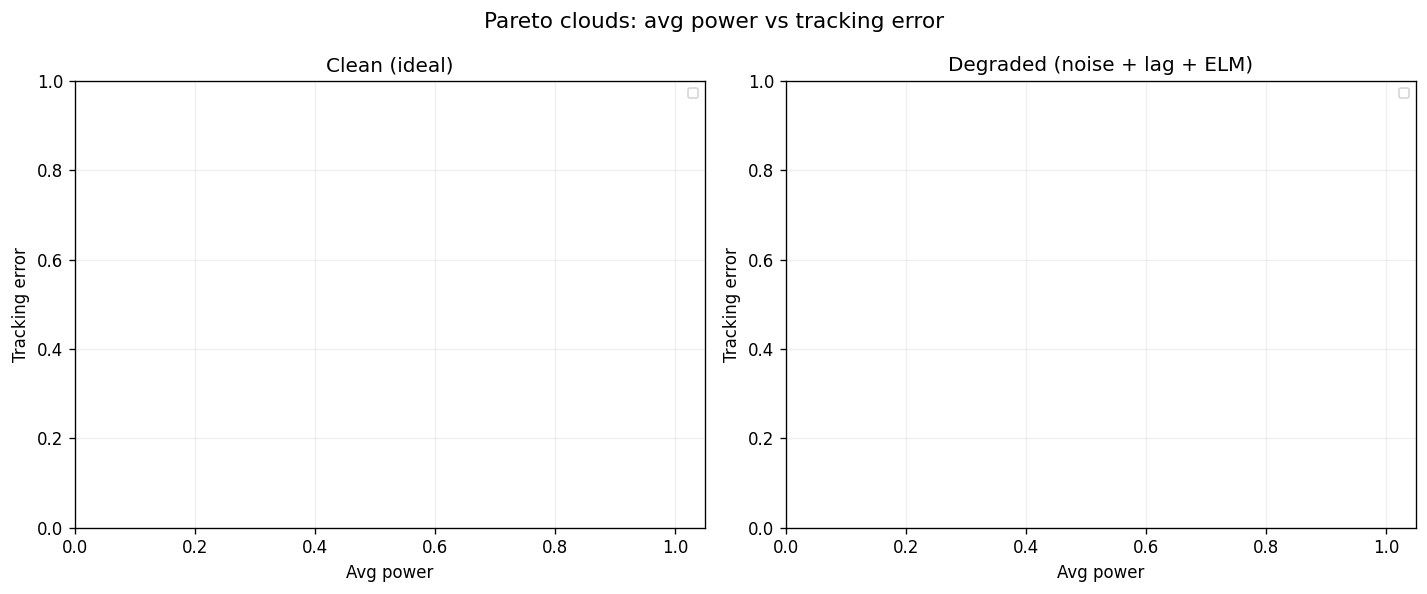

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, title in [(ax1, res_clean, "Clean (ideal)"),
                        (ax2, res_deg, "Degraded (noise + lag + ELM)")]:
    for pts, color, marker, label in [
        (res["const"], "steelblue", "o", "Constant"),
        (res["pulse"], "crimson", "s", "Pulse train"),
        (res["kick"], "seagreen", "^", "Kick-hold"),
    ]:
        if pts:
            xs, ys = zip(*pts)
            ax.scatter(xs, ys, c=color, s=15, alpha=0.5, marker=marker, label=label)
    ax.set_xlabel("Avg power")
    ax.set_ylabel("Tracking error")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.grid(True, alpha=0.2)

fig.suptitle("Pareto clouds: avg power vs tracking error", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Time-series: best controllers head-to-head

For each controller type, we pick the one with the **lowest avg power** among feasible configs
and overlay their trajectories.

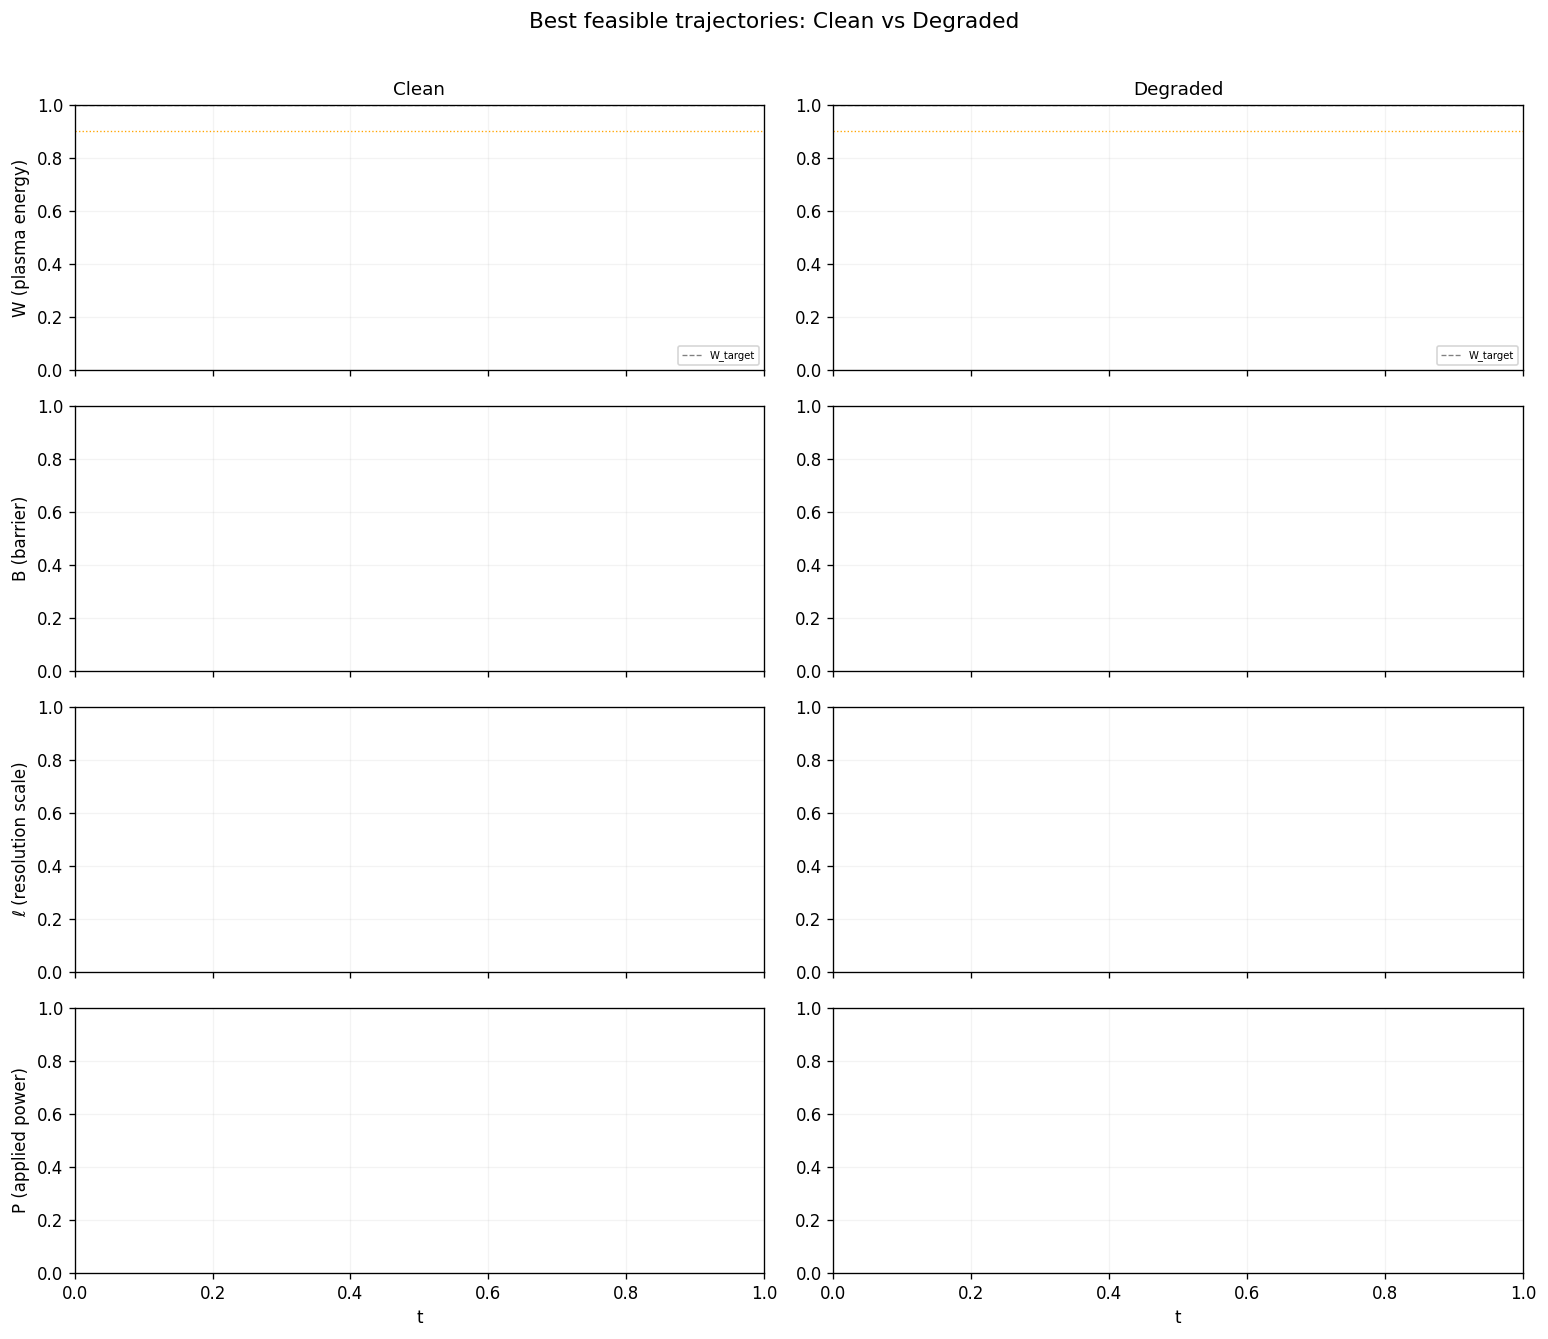

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(13, 11), sharex="col")
fig.suptitle("Best feasible trajectories: Clean vs Degraded", fontsize=13, y=1.01)

for col, (bests, title) in enumerate([(best_clean, "Clean"),
                                       (best_deg, "Degraded")]):
    for key, color, label in [("const", "steelblue", "Constant"),
                               ("pulse", "crimson", "Pulse"),
                               ("kick", "seagreen", "Kick-hold")]:
        data = bests[key]
        if data is None:
            continue
        t, W, B, ell_arr, P, m = data
        tag = f"{label}  P\u0304={m['avg_power']:.3f}  err={m['tracking_error']:.2f}"
        axes[0, col].plot(t, W, color=color, lw=1.3, alpha=0.85, label=tag)
        axes[1, col].plot(t, B, color=color, lw=1.3, alpha=0.85)
        axes[2, col].plot(t, ell_arr, color=color, lw=1.0, alpha=0.8)
        axes[3, col].plot(t, P, color=color, lw=0.7, alpha=0.7)

    axes[0, col].axhline(W_TARGET, ls="--", c="grey", lw=0.8, label="W_target")
    axes[0, col].axhline(W_MIN_FRAC * W_TARGET, ls=":", c="orange", lw=0.8)
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].legend(fontsize=6, loc="lower right")
    axes[3, col].set_xlabel("t")

for row, ylabel in enumerate(["W (plasma energy)", "B (barrier)",
                               "\u2113 (resolution scale)", "P (applied power)"]):
    axes[row, 0].set_ylabel(ylabel)
    for c in range(2):
        axes[row, c].grid(True, alpha=0.15)

fig.tight_layout()
plt.show()


## 5. Periodic observe-then-act: frequency optimisation

The controllers above use fixed open-loop schedules. A smarter approach
**separates observation and actuation phases**:

1. **Observe** ($T_\text{obs}$): reduce power to $P_\text{hold}$, let $\ell$
   relax, collect $W$ measurements and average them.
2. **Act** ($T_\text{act}$): apply a proportional correction
   $P = \text{clip}(K \cdot (W_\text{target} - \bar{W}_\text{obs}),\, 0,\, P_\text{max})$.

The key ratio is $T_\text{obs} / \tau_\ell$:
- Too small → $\ell$ doesn’t relax, observations are noisy
- Too large → plasma drifts too far during observation, barrier may collapse
- Optimal → best trade-off, potentially beating continuous control


In [ ]:
def make_periodic_observe_act(W_target, K_act, P_hold_frac, T_obs, T_act, P_max):
    '''
    Periodic observe-then-act controller for plasma model.
    During observe phase: P = P_hold (low power, let ell relax).
    During act phase: P = clip(K_act * (W_target - W_avg), 0, P_max).
    '''
    P_hold = P_hold_frac * P_max

    def controller(t, W, B, state=None):
        if state is None:
            state = (0.0, 0.0, 0, P_hold)  # (obs_sum, obs_count, cycle_start_step, P_act)
        obs_sum, obs_count, cycle_start, P_act = state

        cycle_len = T_obs + T_act
        if cycle_len <= 0:
            return P_hold, state

        phase = t % cycle_len

        if phase < T_obs:
            # Observation phase: low power, accumulate measurements
            obs_sum += W
            obs_count += 1
            # At end of obs phase, compute action
            if phase + 0.005 >= T_obs and obs_count > 0:  # near transition
                W_avg = obs_sum / obs_count
                P_act = np.clip(K_act * (W_target - W_avg), 0.0, P_max)
                obs_sum = 0.0
                obs_count = 0
            return P_hold, (obs_sum, obs_count, cycle_start, P_act)
        else:
            # Action phase: apply computed power
            return P_act, (0.0, 0, cycle_start, P_act)

    return controller


In [ ]:
import time as time_mod

# Parameters for the sweep
tau_ell = SAMPLE['tau_ell_frac'] * SAMPLE['tauB']
T_ACT = 1.0  # fixed action time
K_ACT_GRID = [1.0, 2.0, 4.0]
P_HOLD_OBS = 0.05  # fraction of P_max during observation

T_obs_grid = np.concatenate([
    np.arange(0.1, 0.5, 0.1),
    np.arange(0.5, 2.01, 0.25),
    np.arange(2.5, 5.01, 0.5),
])

# Find best continuous controller (from previous sweep)
best_const_err = 1e9
best_const_pow = 1e9
params_clean = params_from_sample({**SAMPLE, 'noise_seed': 42}, P_MAX)
dt_clean = choose_dt(params_clean['tau0'], params_clean['tauB'], params_clean.get('tau_ell', 1.0))
ell0_clean = params_clean.get('ell0', 0.0)

for P_frac in np.linspace(0.3, 1.0, 15):
    ctrl = make_constant(P_frac * P_MAX, P_MAX)
    t_s, W_s, B_s, ell_s, P_s = run_simulation(ctrl, T_TOTAL, dt_clean, params_clean)
    m = compute_metrics(t_s, W_s, B_s, ell_s, P_s, W_TARGET, W_MIN_FRAC, ell0=ell0_clean)
    if m['time_below'] <= FEASIBILITY_TOL and m['tracking_error'] < best_const_err:
        best_const_err = m['tracking_error']
        best_const_pow = m['avg_power']

print(f'Best continuous: tracking_error={best_const_err:.4f}, avg_power={best_const_pow:.4f}')
print(f'tau_ell = {tau_ell:.2f}')
print()

# Sweep T_obs for each K_act
sweep_results = {}  # K_act -> {T_obs_list, err_list, pow_list, feasible_list}

t0_sweep = time_mod.time()
for Ka in K_ACT_GRID:
    errs, pows, feas = [], [], []
    for To in T_obs_grid:
        ctrl = make_periodic_observe_act(W_TARGET, Ka, P_HOLD_OBS, To, T_ACT, P_MAX)
        t_s, W_s, B_s, ell_s, P_s = run_simulation(ctrl, T_TOTAL, dt_clean, params_clean)
        m = compute_metrics(t_s, W_s, B_s, ell_s, P_s, W_TARGET, W_MIN_FRAC, ell0=ell0_clean)
        errs.append(m['tracking_error'])
        pows.append(m['avg_power'])
        feas.append(m['time_below'] <= FEASIBILITY_TOL)
    sweep_results[Ka] = {'T_obs': T_obs_grid.copy(), 'err': errs, 'pow': pows, 'feas': feas}
    best_idx = np.argmin(errs)
    print(f'K_act={Ka:.1f}: best T_obs={T_obs_grid[best_idx]:.2f}, '
          f'err={errs[best_idx]:.4f}, pow={pows[best_idx]:.4f}, '
          f'feasible={feas[best_idx]}')

elapsed = time_mod.time() - t0_sweep
print(f'\nSweep done in {elapsed:.0f}s')


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors_k = ['#e74c3c', '#2ecc71', '#3498db']
for idx, Ka in enumerate(K_ACT_GRID):
    sr = sweep_results[Ka]
    ratio = np.array(sr['T_obs']) / tau_ell
    ax1.plot(ratio, sr['err'], 'o-', ms=5, color=colors_k[idx],
             label=f'periodic K={Ka:.0f}')
    ax2.plot(ratio, sr['pow'], 'o-', ms=5, color=colors_k[idx],
             label=f'periodic K={Ka:.0f}')

ax1.axhline(best_const_err, ls='--', c='black', lw=1.5, label='best continuous')
ax1.set_xlabel(r'$T_{\mathrm{obs}} \,/\, \tau_\ell$')
ax1.set_ylabel('Tracking error')
ax1.set_title('Error vs observation time')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)

ax2.axhline(best_const_pow, ls='--', c='black', lw=1.5, label='best continuous')
ax2.set_xlabel(r'$T_{\mathrm{obs}} \,/\, \tau_\ell$')
ax2.set_ylabel('Avg power')
ax2.set_title('Power vs observation time')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

fig.suptitle(r'Periodic observe-then-act: $T_{\mathrm{obs}}/\tau_\ell$ sweep',
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


In [ ]:
# Repeat sweep with degradation
params_deg = params_from_sample({**SAMPLE, **DEGRADATION, 'noise_seed': 42}, P_MAX)
dt_deg = choose_dt(params_deg['tau0'], params_deg['tauB'], params_deg.get('tau_ell', 1.0))
ell0_deg = params_deg.get('ell0', 0.0)

best_const_err_deg = 1e9
best_const_pow_deg = 1e9
for P_frac in np.linspace(0.3, 1.0, 15):
    ctrl = make_constant(P_frac * P_MAX, P_MAX)
    t_s, W_s, B_s, ell_s, P_s = run_simulation(ctrl, T_TOTAL, dt_deg, params_deg)
    m = compute_metrics(t_s, W_s, B_s, ell_s, P_s, W_TARGET, W_MIN_FRAC, ell0=ell0_deg)
    if m['time_below'] <= FEASIBILITY_TOL and m['tracking_error'] < best_const_err_deg:
        best_const_err_deg = m['tracking_error']
        best_const_pow_deg = m['avg_power']

sweep_deg = {}
t0_deg = time_mod.time()
for Ka in K_ACT_GRID:
    errs, pows, feas = [], [], []
    for To in T_obs_grid:
        ctrl = make_periodic_observe_act(W_TARGET, Ka, P_HOLD_OBS, To, T_ACT, P_MAX)
        t_s, W_s, B_s, ell_s, P_s = run_simulation(ctrl, T_TOTAL, dt_deg, params_deg)
        m = compute_metrics(t_s, W_s, B_s, ell_s, P_s, W_TARGET, W_MIN_FRAC, ell0=ell0_deg)
        errs.append(m['tracking_error'])
        pows.append(m['avg_power'])
        feas.append(m['time_below'] <= FEASIBILITY_TOL)
    sweep_deg[Ka] = {'T_obs': T_obs_grid.copy(), 'err': errs, 'pow': pows, 'feas': feas}

elapsed_deg = time_mod.time() - t0_deg
print(f'Best continuous (degraded): err={best_const_err_deg:.4f}, pow={best_const_pow_deg:.4f}')
for Ka in K_ACT_GRID:
    sr = sweep_deg[Ka]
    bi = np.argmin(sr['err'])
    print(f'  K={Ka}: best T_obs={T_obs_grid[bi]:.2f}, err={sr["err"][bi]:.4f}, '
          f'pow={sr["pow"][bi]:.4f}, feasible={sr["feas"][bi]}')
print(f'Degraded sweep: {elapsed_deg:.0f}s')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sr_dict, best_err, title in [
    (axes[0], sweep_results, best_const_err, 'Clean (ideal)'),
    (axes[1], sweep_deg, best_const_err_deg, 'Degraded (noise + lag + ELM)'),
]:
    for idx, Ka in enumerate(K_ACT_GRID):
        sr = sr_dict[Ka]
        ratio = np.array(sr['T_obs']) / tau_ell
        ax.plot(ratio, sr['err'], 'o-', ms=5, color=colors_k[idx],
                label=f'periodic K={Ka:.0f}')
    ax.axhline(best_err, ls='--', c='black', lw=1.5, label='best continuous')
    ax.set_xlabel(r'$T_{\mathrm{obs}} \,/\, \tau_\ell$')
    ax.set_ylabel('Tracking error')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle(r'Tracking error vs $T_{\mathrm{obs}}/\tau_\ell$: Clean vs Degraded',
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


### Interpretation

- The **U-shaped curve** shows there is an optimal $T_\text{obs}/\tau_\ell$
  ratio: enough time for $\ell$ to relax, but not so long that the plasma
  drifts uncontrollably.
- When the curve dips **below** the dashed line, the periodic controller
  **outperforms** the best constant-power controller.
- Under degradation (noise, actuator lag, ELMs), the advantage may shift
  or become more pronounced — precisely the regime where
  $\ell$-mediated degradation matters most.


## 5. Power savings summary

How much power does pulsed control save vs the best constant controller?

In [7]:
err_cap = 0.5

for label, res in [("Clean", res_clean), ("Degraded", res_deg)]:
    c_ok = [p for p, e in res["const"] if e < err_cap]
    all_pulsed = res["pulse"] + res["kick"]
    p_ok = [p for p, e in all_pulsed if e < err_cap]
    if c_ok and p_ok:
        bc, bp = min(c_ok), min(p_ok)
        saving = (bc - bp) / bc * 100
        print(f"{label:10s}  best_const_power={bc:.3f}  best_pulse_power={bp:.3f}  "
              f"saving={saving:+.1f}%")
    else:
        print(f"{label:10s}  insufficient feasible points")

print("\n---")
print("For the full 4-regime comparison with dense grids, run:")
print("  python -u run_comparison.py")

Clean       insufficient feasible points
Degraded    insufficient feasible points

---
For the full 4-regime comparison with dense grids, run:
  python -u run_comparison.py
